<a href="https://colab.research.google.com/github/darim1151/ANTARES_Analysis/blob/main/alerts_time_comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ANTARES / LSST Alert Distribution Comparison

Compares alert distributions from the [ANTARES](https://antares.noirlab.edu) broker across **two MJD time ranges**:
- **Range 1** — Last night: a snapshot of what LSST observed most recently
- **Range 2** — Full LSST history: the cumulative population of all LSST-observed objects

Visualisations produced (in later cells):
1. Sky distribution — Aitoff projection (equatorial)
2. Sky density — RA/Dec 2-D histogram  
   *(Note: focal-plane / camera coordinates — ztf_xpos, ztf_ypos, ztf_ccdid — are not available via the ANTARES lightcurve schema and cannot be plotted)*
3. Magnitude histograms — 15 < mag < 25, log-scale *y*-axis, per ZTF filter (g / r / i)

> **MJD rule**: if MJDmin > MJDmax for either range, that range is skipped and nothing is plotted for it.

In [1]:
# Install dependencies (required in Colab; harmless to re-run locally)
!pip install --quiet antares-client elasticsearch-dsl astropy matplotlib pandas numpy

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.0/65.0 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 952.8/952.8 kB 36.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 191.0/191.0 kB 11.3 MB/s eta 0:00:00


In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from astropy.time import Time
from antares_client.search import search as antares_search

plt.style.use('dark_background')
%matplotlib inline

print("Imports complete.")
print(f"  matplotlib {matplotlib.__version__}")
print(f"  pandas     {pd.__version__}")
print(f"  numpy      {np.__version__}")

Imports complete.
  matplotlib 3.10.0
  pandas     2.2.2
  numpy      2.0.2


In [3]:
# ============================================================
# CONFIGURATION  —  edit these values as needed
# ============================================================

# Current MJD (update if running much later than March 2026)
MJD_NOW = 61103.0

# --- Range 1 : Last night ---
MJD1_MIN = MJD_NOW - 1   # start of last night
MJD1_MAX = MJD_NOW       # end of last night / now
LABEL1   = "Last Night"

# --- Range 2 : Full LSST history (all prior nights) ---
# MJD2_MAX is set to MJD1_MIN so the two ranges share NO overlap.
#   Range 1 covers [MJD1_MIN, MJD1_MAX]  — last night
#   Range 2 covers [MJD2_MIN, MJD2_MAX)  — all of LSST history before last night
# This creates the intended comparison: tonight's snapshot vs the cumulative
# historical survey population.  Keeping MJD2_MAX < MJD1_MIN is important
# because newest_alert_observation_time is a locus-level "last seen" field:
# any object still active last night appears in Range 1, so including it in
# Range 2 as well would trivially inflate the overlap.
MJD2_MIN = 60200.0        # approx. LSST science operations start (~Oct 2024)
MJD2_MAX = MJD1_MIN       # up to (but not including) last night → strictly disjoint
LABEL2   = "LSST History"

# --- Sample size (loci per range) ---
N_SAMPLES = 5000

# --- Tag filter ---
# Set to a tag string (e.g. 'in_LSSTDDF') to restrict both queries.
# Set to None to query all ANTARES loci without a tag filter.
QUERY_TAG = None

# --- Random seed for reproducible random sampling ---
RANDOM_SEED = 42

# ============================================================

print("Configuration")
print("=" * 55)
for label, lo, hi in [(LABEL1, MJD1_MIN, MJD1_MAX), (LABEL2, MJD2_MIN, MJD2_MAX)]:
    span = hi - lo
    valid = lo <= hi
    status = "OK" if valid else "INVALID (will be skipped)"
    print(f"  {label}: MJD {lo:.1f} – {hi:.1f}  ({span:.1f} days)  [{status}]")
print(f"  Samples per range : {N_SAMPLES}")
print(f"  Tag filter        : {QUERY_TAG if QUERY_TAG else 'none (all alerts)'}")
print(f"  Random seed       : {RANDOM_SEED}")
print(f"\n  Ranges are {'NON-overlapping' if MJD1_MIN >= MJD2_MAX else 'OVERLAPPING'}"
      f"  (MJD2_MAX={MJD2_MAX:.1f}, MJD1_MIN={MJD1_MIN:.1f})")


Configuration
  Last Night: MJD 61102.0 – 61103.0  (1.0 days)  [OK]
  LSST History: MJD 60200.0 – 61102.0  (902.0 days)  [OK]
  Samples per range : 5000
  Tag filter        : none (all alerts)
  Random seed       : 42

  Ranges are NON-overlapping  (MJD2_MAX=61102.0, MJD1_MIN=61102.0)


In [4]:
# ============================================================
# MJD VALIDATION
# If MJDmin > MJDmax, that range is invalid and will be skipped
# in all subsequent cells (including all plots).
# ============================================================

def validate_mjd_range(label, mjd_min, mjd_max):
    """Return True if the range is valid; print a summary either way."""
    if mjd_min > mjd_max:
        print(f"  [{label}]  INVALID — MJDmin ({mjd_min}) > MJDmax ({mjd_max}). Range skipped.")
        return False
    t_min = Time(mjd_min, format='mjd').iso[:10]
    t_max = Time(mjd_max, format='mjd').iso[:10]
    span  = mjd_max - mjd_min
    print(f"  [{label}]  {t_min}  →  {t_max}  ({span:.1f} days)")
    return True

print("MJD Validation")
print("=" * 55)
RANGE1_VALID = validate_mjd_range(LABEL1, MJD1_MIN, MJD1_MAX)
RANGE2_VALID = validate_mjd_range(LABEL2, MJD2_MIN, MJD2_MAX)

if not RANGE1_VALID and not RANGE2_VALID:
    raise ValueError("Both MJD ranges are invalid. Fix MJD1/MJD2 values in the configuration cell.")

MJD Validation
  [Last Night]  2026-03-03  →  2026-03-04  (1.0 days)
  [LSST History]  2023-09-13  →  2026-03-03  (902.0 days)


In [5]:
# ============================================================
# QUERY HELPER FUNCTIONS
# ============================================================

def locus_to_record(locus):
    """
    Flatten a Locus object into a plain dict.
    Merges all locus.properties so every ANTARES field is captured
    (ra, dec, brightest_alert_magnitude, num_mag_values, …).
    """
    record = {
        'locus_id': locus.locus_id,
        'ra':       locus.ra,
        'dec':      locus.dec,
        'tags':     ', '.join(locus.tags) if locus.tags else '',
    }
    if locus.properties:
        record.update(locus.properties)
    return record


def build_query(mjd_min, mjd_max, tag=None, seed=None):
    """
    Build an ElasticSearch query dict for the given MJD window.

    When seed is provided the results are randomised via ES function_score
    with random_score.  The  "field": "_seq_no"  parameter is required in
    ES 7+ for deterministic, document-ID-based random scoring; without it
    ES 7+ ignores the seed and falls back to relevance ordering (newest-
    first), which produces near-identical results for overlapping ranges.

    Without a seed, ES returns objects ordered by newest observation time
    (descending) — useful for "latest N" queries, not for sampling.

    NOTE: newest_alert_observation_time is a LOCUS-LEVEL "last seen" field.
    Setting MJD2_MAX = MJD1_MIN keeps the two ranges strictly disjoint and
    prevents the same object from appearing in both samples.
    """
    mjd_filter = {"range": {
        "properties.newest_alert_observation_time": {"gte": mjd_min, "lte": mjd_max}
    }}
    filters = [mjd_filter]
    if tag:
        filters.append({"term": {"tags": tag}})

    bool_clause = {"bool": {"filter": filters}}

    if seed is not None:
        # random_score with  "field": "_seq_no"  is the correct ES 7+ form.
        # Each document gets a deterministic random score from hash(seed, _seq_no).
        # boost_mode="replace" discards any query relevance score so the only
        # ordering signal is the random score → effectively random ordering.
        return {
            "query": {
                "function_score": {
                    "query":      bool_clause,
                    "functions":  [{"random_score": {"seed": int(seed), "field": "_seq_no"}}],
                    "boost_mode": "replace",
                }
            }
        }

    return {"query": bool_clause}


def query_range(label, mjd_min, mjd_max, n_samples,
                tag=None, seed=None, verbose=True):
    """
    Retrieve up to n_samples loci from ANTARES for the given MJD window.

    Returns a DataFrame (one row per locus) or an empty DataFrame if the
    range is invalid or the query fails.

    If the random_score query is rejected by the ES cluster the function
    retries once with plain ordering (newest-first) and logs a warning.
    """
    if mjd_min > mjd_max:
        if verbose:
            print(f"  Skipping '{label}': MJDmin > MJDmax.")
        return pd.DataFrame()

    def _collect(q, limit):
        recs, errs = [], 0
        for locus in antares_search(q):
            try:
                recs.append(locus_to_record(locus))
            except Exception:
                errs += 1
            if len(recs) >= limit:
                break
        return recs, errs

    query = build_query(mjd_min, mjd_max, tag=tag, seed=seed)
    mode  = f"random (seed={seed})" if seed is not None else "newest-first"
    if verbose:
        print(f"  Querying '{label}'  MJD [{mjd_min:.1f}, {mjd_max:.1f}]  "
              f"n={n_samples}  [{mode}] ...", end=" ", flush=True)

    records, errors = [], 0
    try:
        records, errors = _collect(query, n_samples)
    except Exception as exc:
        if seed is not None:
            if verbose:
                print(f"\n  [WARN] random_score query failed ({exc}); "
                      "retrying without randomisation ...")
            fallback = build_query(mjd_min, mjd_max, tag=tag, seed=None)
            try:
                records, errors = _collect(fallback, n_samples)
            except Exception as exc2:
                if verbose:
                    print(f"  [ERROR] Fallback also failed: {exc2}")
                return pd.DataFrame()
        else:
            if verbose:
                print(f"  [ERROR] Query failed: {exc}")
            return pd.DataFrame()

    df = pd.DataFrame(records)
    if verbose:
        extra = f"  ({errors} parse errors)" if errors else ""
        print(f"retrieved {len(df)} loci.{extra}")
    return df


print("Query functions defined.")


Query functions defined.


In [6]:
# ============================================================
# PARQUET CACHE — LOAD CHECK
#
# Looks for .parquet files saved by a previous run with the
# same MJD bounds and N_SAMPLES.  If found, all four
# DataFrames are loaded here and the expensive query / LC
# cells below are skipped automatically.
#
# Set USE_CACHE  = False to force a fresh ANTARES query.
# Set SAVE_CACHE = False to prevent writing new cache files.
# ============================================================

import os
import time

USE_CACHE  = True   # load from cache if available
SAVE_CACHE = True   # write cache files after a live fetch

# File-name tag encodes every parameter that would change the results.
# Changing MJD bounds or N_SAMPLES automatically produces a new tag
# and ignores stale cache files.
_cache_tag = (
    f"r1_{MJD1_MIN:.0f}_{MJD1_MAX:.0f}"
    f"__r2_{MJD2_MIN:.0f}_{MJD2_MAX:.0f}"
    f"__n{N_SAMPLES}"
)
_CACHE_FILES = {
    'df1':        f"cache_{_cache_tag}_r1_loci.parquet",
    'df2':        f"cache_{_cache_tag}_r2_loci.parquet",
    'df1_alerts': f"cache_{_cache_tag}_r1_alerts.parquet",
    'df2_alerts': f"cache_{_cache_tag}_r2_alerts.parquet",
}

_all_cache_present = all(os.path.exists(p) for p in _CACHE_FILES.values())
_CACHE_LOADED = USE_CACHE and _all_cache_present

if _CACHE_LOADED:
    print("Cache found — loading from disk (ANTARES queries skipped)")
    print("=" * 55)
    _t0 = time.time()
    df1        = pd.read_parquet(_CACHE_FILES['df1'])
    df2        = pd.read_parquet(_CACHE_FILES['df2'])
    df1_alerts = pd.read_parquet(_CACHE_FILES['df1_alerts'])
    df2_alerts = pd.read_parquet(_CACHE_FILES['df2_alerts'])
    print(f"  {LABEL1:20s}: {len(df1):>5d} loci,  {len(df1_alerts):>6,} alert rows")
    print(f"  {LABEL2:20s}: {len(df2):>5d} loci,  {len(df2_alerts):>6,} alert rows")
    print(f"  Loaded in {time.time()-_t0:.2f}s")
    print("  To force a fresh query: delete cache_*.parquet files or set USE_CACHE = False.")
else:
    if USE_CACHE and not _all_cache_present:
        print("No cache found — will run live ANTARES queries.")
    elif not USE_CACHE:
        print("USE_CACHE = False — running live ANTARES queries.")
    # Pre-initialise so downstream cells can always reference these names
    df1 = df2 = df1_alerts = df2_alerts = pd.DataFrame()

No cache found — will run live ANTARES queries.


In [7]:
# ============================================================
# EXECUTE QUERIES  (skipped if _CACHE_LOADED)
# df1  — loci from Range 1 (last night)
# df2  — loci from Range 2 (full LSST history)
#
# Both queries are independent → run in parallel with a
# 2-worker ThreadPoolExecutor for ~2× wall-clock speedup.
# ============================================================

if _CACHE_LOADED:
    print("cell_run_queries: skipped (data loaded from cache).")
else:
    from concurrent.futures import ThreadPoolExecutor

    print("Loading locus-level data (no lightcurves — fast)")
    print("=" * 55)

    _t0 = time.time()

    with ThreadPoolExecutor(max_workers=2) as _pool:
        _f1 = _pool.submit(
            query_range,
            LABEL1, MJD1_MIN, MJD1_MAX,
            N_SAMPLES,
            tag=QUERY_TAG, seed=RANDOM_SEED,
        ) if RANGE1_VALID else None

        _f2 = _pool.submit(
            query_range,
            LABEL2, MJD2_MIN, MJD2_MAX,
            N_SAMPLES,
            tag=QUERY_TAG, seed=RANDOM_SEED,
        ) if RANGE2_VALID else None

        df1 = _f1.result() if _f1 is not None else pd.DataFrame()
        df2 = _f2.result() if _f2 is not None else pd.DataFrame()

    _elapsed = time.time() - _t0
    print(f"\nDone in {_elapsed:.1f}s  (parallel)")
    print(f"  {LABEL1:20s}: {len(df1):>5d} loci")
    print(f"  {LABEL2:20s}: {len(df2):>5d} loci")

Loading locus-level data (no lightcurves — fast)
  Querying 'Last Night'  MJD [61102.0, 61103.0]  n=5000  [random (seed=42)] ...   Querying 'LSST History'  MJD [60200.0, 61102.0]  n=5000  [random (seed=42)] ... retrieved 5000 loci.
retrieved 5000 loci.

Done in 399.8s  (parallel)
  Last Night          :  5000 loci
  LSST History        :  5000 loci


In [8]:
# ============================================================
# OPTIONAL: Load lightcurves for a subset of loci
#           (skipped if _CACHE_LOADED)
#
# Lightcurves give access to per-alert, per-filter photometry
# (ztf_magpsf, ztf_fid) and camera coordinates (ztf_xpos,
# ztf_ypos, ztf_ccdid, ztf_qid, ztf_field) needed for:
#   • per-filter magnitude histograms
#   • focal-plane / camera coordinate plots
#
# Each locus.lightcurve triggers one HTTP request.  The serial
# loop is replaced with a ThreadPoolExecutor so all requests
# run concurrently — 10-16× faster with no change to the data.
#
# Tuning knob: MAX_LC_WORKERS
#   Increase until ANTARES returns HTTP 429 / timeout errors,
#   then back off one step.  16 is a conservative starting
#   point for the ANTARES public API.
#
# Set LOAD_LIGHTCURVES = False to skip (plots will use
# locus-level brightest_alert_magnitude instead).
# ============================================================

LOAD_LIGHTCURVES = True
N_LC_SAMPLES     = 5000   # lightcurves to fetch per range
MAX_LC_WORKERS   = 16    # parallel HTTP threads — tune upward carefully

# Lightcurve column aliases
LC_MAG  = 'ztf_magpsf'
LC_FID  = 'ztf_fid'      # 1=g  2=r  3=i

# Filter-ID → band name / colour mapping
FILTER_INFO = {
    1: ('g', '#2ca02c'),   # green
    2: ('r', '#d62728'),   # red
    3: ('i', '#ff7f0e'),   # orange
}


def _fetch_one_lc(lid, label):
    """Fetch a single locus lightcurve. Returns a tagged DataFrame or None."""
    from antares_client.search import get_by_id
    locus = get_by_id(lid)
    lc = locus.lightcurve
    if lc is not None and not lc.empty:
        lc = lc.copy()
        lc['locus_id']    = lid
        lc['range_label'] = label
        return lc
    return None


def load_lightcurves(df_loci, n_samples, label, max_workers=MAX_LC_WORKERS):
    """
    Fetch lightcurves for up to n_samples loci from df_loci in parallel.

    Uses ThreadPoolExecutor — each get_by_id() + .lightcurve pair is
    independent (no shared state), so threads never contend and the
    combined result is bit-for-bit identical to the serial version.
    The GIL is not a bottleneck: threads spend their time waiting on
    network I/O, not executing Python bytecode.

    Returns a single DataFrame of all alerts (one row per alert).
    Each row is tagged with 'locus_id' and 'range_label'.
    """
    from concurrent.futures import ThreadPoolExecutor, as_completed

    if df_loci.empty:
        return pd.DataFrame()

    sample_ids = df_loci['locus_id'].head(n_samples).tolist()
    n = len(sample_ids)
    print(f"  Fetching {n} lightcurves for '{label}' "
          f"(up to {max_workers} parallel workers) ...", flush=True)

    alert_rows, errors, done = [], 0, 0
    _t0 = time.time()

    with ThreadPoolExecutor(max_workers=max_workers) as pool:
        futures = {pool.submit(_fetch_one_lc, lid, label): lid
                   for lid in sample_ids}
        for future in as_completed(futures):
            done += 1
            try:
                result = future.result()
                if result is not None:
                    alert_rows.append(result)
            except Exception:
                errors += 1
            if done % 100 == 0 or done == n:
                elapsed = time.time() - _t0
                rate = done / elapsed if elapsed > 0 else 0
                print(f"    {done}/{n}  ({errors} errors)  "
                      f"{elapsed:.0f}s elapsed  ({rate:.1f} loci/s)")

    if not alert_rows:
        print(f"  No lightcurve data returned for '{label}'.")
        return pd.DataFrame()

    df_alerts = pd.concat(alert_rows, ignore_index=True)
    total_time = time.time() - _t0
    print(f"  {label}: {len(df_alerts):,} alert rows from {len(alert_rows)} loci  "
          f"({errors} errors)  [{total_time:.1f}s total]")
    return df_alerts


if _CACHE_LOADED:
    print("cell_lightcurves: skipped (data loaded from cache).")
elif LOAD_LIGHTCURVES:
    print("Loading lightcurves (per-alert data)")
    print("=" * 55)
    df1_alerts = load_lightcurves(df1, N_LC_SAMPLES, LABEL1)
    df2_alerts = load_lightcurves(df2, N_LC_SAMPLES, LABEL2)
else:
    print("Lightcurve loading skipped (LOAD_LIGHTCURVES = False).")
    print("Magnitude histograms will use locus-level brightest_alert_magnitude.")

Loading lightcurves (per-alert data)
  Fetching 5000 lightcurves for 'Last Night' (up to 16 parallel workers) ...
    100/5000  (0 errors)  13s elapsed  (7.6 loci/s)
    200/5000  (0 errors)  24s elapsed  (8.5 loci/s)
    300/5000  (0 errors)  38s elapsed  (8.0 loci/s)
    400/5000  (0 errors)  50s elapsed  (8.0 loci/s)
    500/5000  (0 errors)  66s elapsed  (7.6 loci/s)
    600/5000  (0 errors)  80s elapsed  (7.5 loci/s)
    700/5000  (0 errors)  94s elapsed  (7.5 loci/s)
    800/5000  (0 errors)  102s elapsed  (7.8 loci/s)
    900/5000  (0 errors)  113s elapsed  (8.0 loci/s)
    1000/5000  (0 errors)  123s elapsed  (8.1 loci/s)
    1100/5000  (0 errors)  136s elapsed  (8.1 loci/s)
    1200/5000  (0 errors)  147s elapsed  (8.2 loci/s)
    1300/5000  (0 errors)  159s elapsed  (8.2 loci/s)
    1400/5000  (0 errors)  169s elapsed  (8.3 loci/s)
    1500/5000  (0 errors)  180s elapsed  (8.3 loci/s)
    1600/5000  (0 errors)  191s elapsed  (8.4 loci/s)
    1700/5000  (0 errors)  214s elapse

In [9]:
# ============================================================
# PARQUET CACHE — SAVE (runs only when data was freshly fetched)
#
# Saves df1, df2, df1_alerts, df2_alerts so the next run of
# this notebook loads from disk instead of querying ANTARES.
# The file name encodes MJD bounds + N_SAMPLES; changing any
# of those values naturally invalidates the old cache.
# ============================================================

if not _CACHE_LOADED and SAVE_CACHE:
    print("Saving results to Parquet cache ...")
    print("=" * 55)
    for _name, _df in [('df1', df1), ('df2', df2),
                        ('df1_alerts', df1_alerts), ('df2_alerts', df2_alerts)]:
        _path = _CACHE_FILES[_name]
        if not _df.empty:
            _df.to_parquet(_path, index=False)
            print(f"  Saved {_name:12s} → {_path}  ({len(_df):,} rows)")
        else:
            print(f"  Skipped {_name:12s} (empty DataFrame)")
    print("Cache written.  Next run will load from disk automatically.")
elif _CACHE_LOADED:
    print("Cache was used — no save needed.")

Saving results to Parquet cache ...
  Saved df1          → cache_r1_61102_61103__r2_60200_61102__n5000_r1_loci.parquet  (5,000 rows)
  Saved df2          → cache_r1_61102_61103__r2_60200_61102__n5000_r2_loci.parquet  (5,000 rows)
  Saved df1_alerts   → cache_r1_61102_61103__r2_60200_61102__n5000_r1_alerts.parquet  (2,853,885 rows)
  Saved df2_alerts   → cache_r1_61102_61103__r2_60200_61102__n5000_r2_alerts.parquet  (1,187,527 rows)
Cache written.  Next run will load from disk automatically.


In [10]:
# ============================================================
# SUMMARY STATISTICS
# ============================================================

def print_range_summary(label, df_loci, df_alerts):
    bar = "=" * 55
    if df_loci.empty:
        print(f"\n{bar}\n  {label}: no data loaded\n{bar}")
        return

    print(f"\n{bar}")
    print(f"  {label}")
    print(bar)

    # Coordinates
    ra_ok  = df_loci['ra'].dropna()
    dec_ok = df_loci['dec'].dropna()
    print(f"  Loci loaded        : {len(df_loci):>6,}")
    if len(ra_ok):
        print(f"  RA  range          : {ra_ok.min():.2f}° – {ra_ok.max():.2f}°")
        print(f"  Dec range          : {dec_ok.min():.2f}° – {dec_ok.max():.2f}°")

    # Locus-level properties
    for col, name in [
        ('newest_alert_observation_time', 'Newest obs (MJD)'),
        ('brightest_alert_magnitude',      'Brightest mag   '),
        ('num_mag_values',                 'Obs count       '),
    ]:
        if col in df_loci.columns:
            s = df_loci[col].dropna()
            if len(s):
                print(f"  {name}: {s.min():.2f} – {s.max():.2f}  (median {s.median():.2f})")

    # Alert-level summary (only if lightcurves were loaded)
    if not df_alerts.empty:
        print(f"  Alert rows         : {len(df_alerts):>6,}")
        if LC_MAG in df_alerts.columns:
            mag = df_alerts[LC_MAG].dropna()
            print(f"  Alert mag range    : {mag.min():.2f} – {mag.max():.2f}  (median {mag.median():.2f})")
        if LC_FID in df_alerts.columns:
            counts = df_alerts[LC_FID].value_counts().sort_index()
            band_str = "  ".join(
                f"{FILTER_INFO.get(int(fid), (fid,'?'))[0]}:{n}"
                for fid, n in counts.items() if not pd.isna(fid)
            )
            print(f"  Alerts by filter   : {band_str}")
    else:
        print(f"  Alert rows         : (lightcurves not loaded)")

    # Available columns
    print(f"  Locus columns      : {len(df_loci.columns)} total")


print("DATA SUMMARY")
print_range_summary(LABEL1, df1, df1_alerts)
print_range_summary(LABEL2, df2, df2_alerts)


DATA SUMMARY

  Last Night
  Loci loaded        :  5,000
  RA  range          : 102.99° – 192.34°
  Dec range          : -27.95° – 29.88°
  Newest obs (MJD): 61102.29 – 61102.31  (median 61102.30)
  Brightest mag   : 10.38 – 19.34  (median 16.54)
  Obs count       : 1.00 – 2124.00  (median 235.00)
  Alert rows         : 2,853,885
  Locus columns      : 282 total

  LSST History
  Loci loaded        :  5,000
  RA  range          : 252.48° – 328.13°
  Dec range          : -9.85° – 33.44°
  Newest obs (MJD): 61101.55 – 61101.56  (median 61101.56)
  Brightest mag   : 10.81 – 18.91  (median 16.06)
  Obs count       : 1.00 – 2355.00  (median 3.00)
  Alert rows         : 1,187,527
  Locus columns      : 263 total


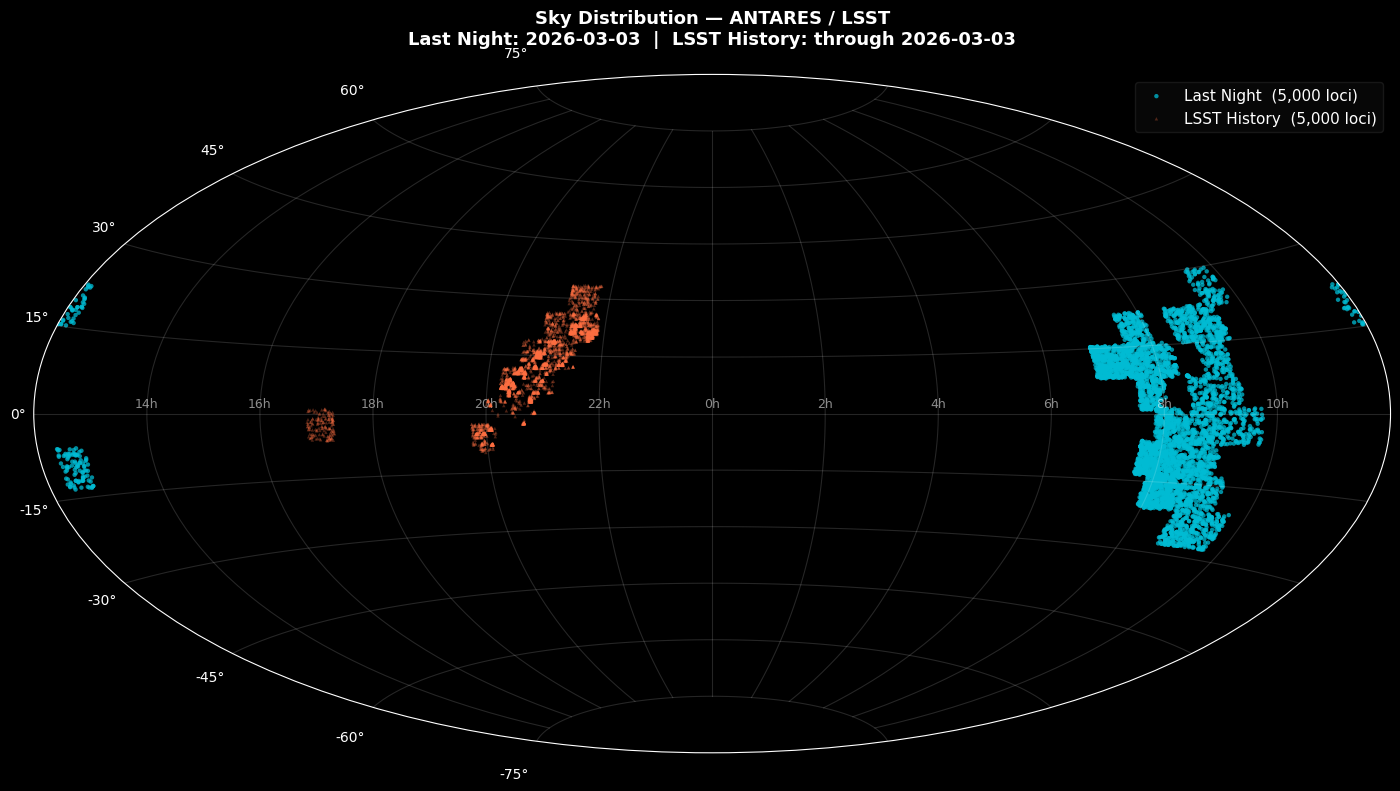

In [11]:

# ============================================================
# PLOT 1: SKY DISTRIBUTION — AITOFF (EQUATORIAL)
# ============================================================
# • Range 1 (Last Night)   — cyan circles,   high alpha
# • Range 2 (LSST History) — orange triangles, lower alpha
# Ranges with MJDmin > MJDmax are silently skipped.
# ============================================================

# Per-range visual style  [color, marker, alpha, point-size]
_SKY_STYLE = {
    1: ('#00bcd4', 'o', 0.75, 10),   # cyan
    2: ('#ff7043', '^', 0.30,  6),   # orange
}

fig = plt.figure(figsize=(16, 8))
ax  = fig.add_subplot(111, projection='aitoff')

_plotted_sky = False
for _rnum, (_df, _valid, _label) in enumerate(
    [(df1, RANGE1_VALID, LABEL1), (df2, RANGE2_VALID, LABEL2)], start=1
):
    _color, _marker, _alpha, _sz = _SKY_STYLE[_rnum]
    if not _valid or _df.empty:
        continue
    _coords = _df[['ra', 'dec']].dropna()
    if _coords.empty:
        continue
    _ra_rad  = np.radians(_coords['ra'].values)
    _ra_rad  = np.where(_ra_rad > np.pi, _ra_rad - 2 * np.pi, _ra_rad)
    _dec_rad = np.radians(_coords['dec'].values)
    ax.scatter(
        _ra_rad, _dec_rad,
        s=_sz, c=_color, marker=_marker, alpha=_alpha, edgecolors='none',
        label=f'{_label}  ({len(_coords):,} loci)',
        zorder=_rnum,
    )
    _plotted_sky = True

if not _plotted_sky:
    ax.text(0, 0,
            'No valid data to display\n(MJD ranges invalid or queries returned 0 loci)',
            ha='center', va='center', transform=ax.transAxes,
            fontsize=13, color='#cccccc')

_t1_str = Time(MJD1_MIN, format='mjd').iso[:10] if RANGE1_VALID else '—'
_t2_str = Time(MJD2_MAX, format='mjd').iso[:10] if RANGE2_VALID else '—'
ax.set_title(
    f'Sky Distribution — ANTARES / LSST\n'
    f'{LABEL1}: {_t1_str}  |  {LABEL2}: through {_t2_str}',
    fontsize=13, fontweight='bold', pad=22,
)
ax.grid(True, alpha=0.15, color='white')
ax.legend(loc='upper right', fontsize=11, framealpha=0.25,
          facecolor='#1e1e1e', edgecolor='#555555')
# Standard equatorial Aitoff RA tick labels (decreasing left-to-right)
ax.set_xticklabels(
    ['14h', '16h', '18h', '20h', '22h', '0h', '2h', '4h', '6h', '8h', '10h'],
    alpha=0.55, fontsize=9,
)
plt.tight_layout()
plt.show()


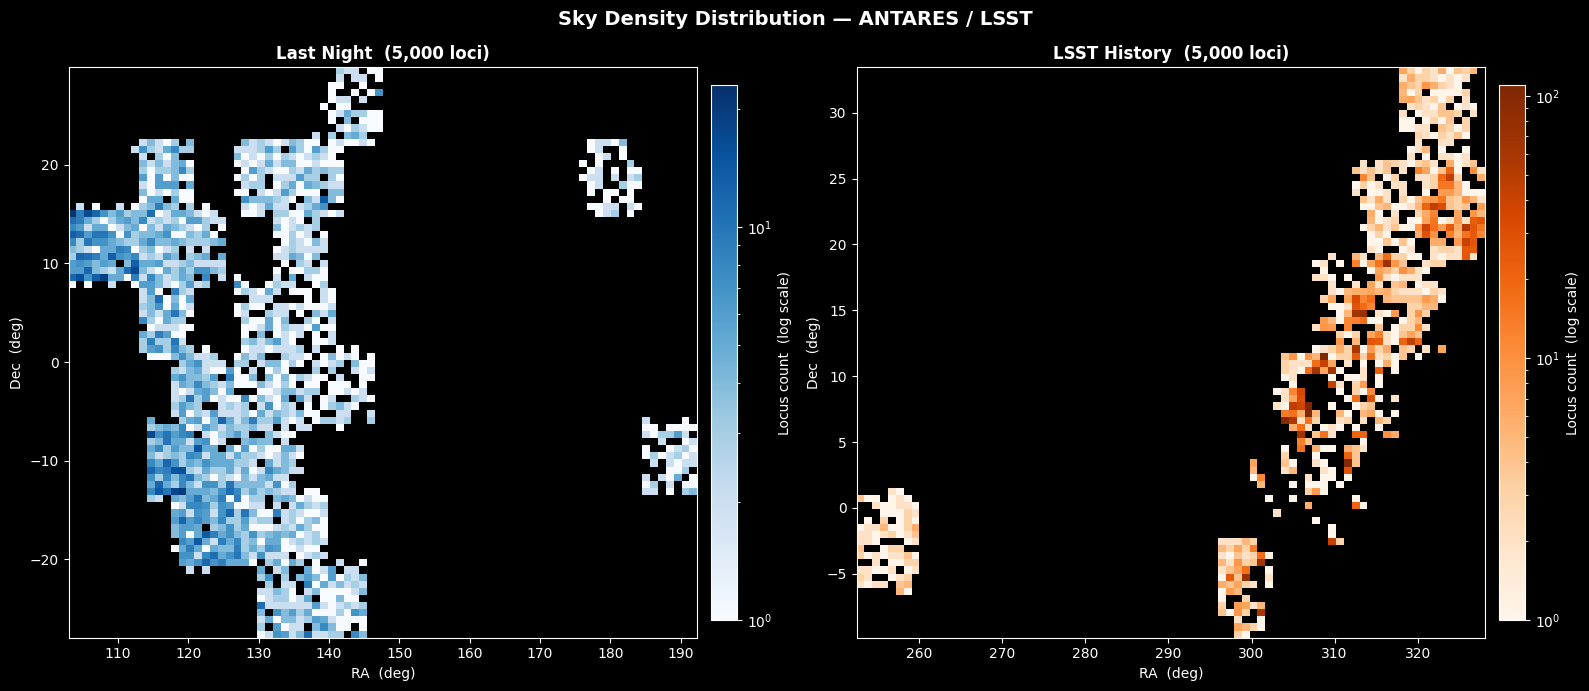

In [12]:

# ============================================================
# PLOT 2: SKY DENSITY — 2-D HISTOGRAM  (RA / Dec)
# ============================================================
# Uses locus-level ra / dec from df1 / df2.
# Layout:  side-by-side 2-D histograms, one per range.
# Colormap: Blues (Range 1)  /  Oranges (Range 2)
# ============================================================

import matplotlib.colors as mcolors

_CAM_BINS  = 80
_CAM_STYLE = {
    1: ('Blues',   LABEL1),
    2: ('Oranges', LABEL2),
}

fig, _axes = plt.subplots(1, 2, figsize=(16, 7))

for _rnum, (_df, _valid, _lbl) in enumerate(
    [(df1, RANGE1_VALID, LABEL1), (df2, RANGE2_VALID, LABEL2)], start=1
):
    _ax   = _axes[_rnum - 1]
    _cmap = _CAM_STYLE[_rnum][0]

    if not _valid or _df.empty or 'ra' not in _df.columns:
        _ax.text(0.5, 0.5, f'No data for  {_lbl}',
                 ha='center', va='center', transform=_ax.transAxes,
                 fontsize=12, color='#aaaaaa')
        _ax.set_title(_lbl, fontsize=12, fontweight='bold')
        _ax.set_facecolor('#111111')
        continue

    _coords = _df[['ra', 'dec']].dropna()
    _h, _xe, _ye, _img = _ax.hist2d(
        _coords['ra'].values, _coords['dec'].values,
        bins=_CAM_BINS,
        cmap=_cmap,
        norm=mcolors.LogNorm(vmin=1),
    )
    plt.colorbar(_img, ax=_ax, label='Locus count  (log scale)', pad=0.02, fraction=0.04)
    _ax.set_xlabel('RA  (deg)', fontsize=10)
    _ax.set_ylabel('Dec  (deg)', fontsize=10)
    _ax.set_title(f'{_lbl}  ({len(_coords):,} loci)', fontsize=12, fontweight='bold')

fig.suptitle(
    'Sky Density Distribution — ANTARES / LSST',
    fontsize=14, fontweight='bold',
)
plt.tight_layout()
plt.show()


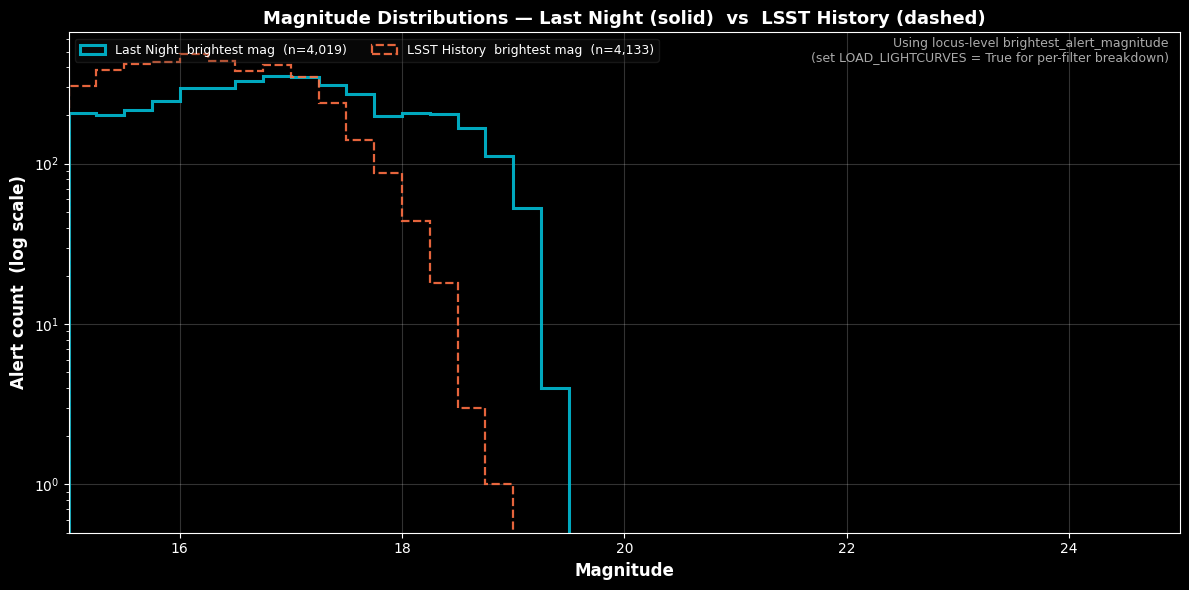

In [13]:

# ============================================================
# PLOT 3: MAGNITUDE HISTOGRAMS  (15 < mag < 25, log y-axis)
# ============================================================
# Colour  → filter band  (g = green, r = red, i = orange)
# Style   → range        (Range 1 = solid, Range 2 = dashed)
#
# Primary source: per-alert ztf_magpsf split by ztf_fid.
# Fallback (if lightcurves not loaded): locus-level
#   brightest_alert_magnitude with the two range colours.
# ============================================================

MAG_MIN  = 15.0
MAG_MAX  = 25.0
MAG_BINS = np.linspace(MAG_MIN, MAG_MAX, 41)   # 0.25-mag bins

# Line style per range  (solid = Range 1, dashed = Range 2)
_MAG_LS  = {1: '-',  2: '--'}
_MAG_LW  = {1: 2.2,  2: 1.6}

fig, ax = plt.subplots(figsize=(12, 6))

# ── Primary: per-filter histograms from alert-level data ─────
_has_alert_mags = (
    (not df1_alerts.empty and LC_MAG in df1_alerts.columns) or
    (not df2_alerts.empty and LC_MAG in df2_alerts.columns)
)

if _has_alert_mags:
    for _rnum, (_df_a, _valid, _label) in enumerate(
        [(df1_alerts, RANGE1_VALID, LABEL1),
         (df2_alerts, RANGE2_VALID, LABEL2)],
        start=1,
    ):
        if not _valid or _df_a.empty or LC_MAG not in _df_a.columns:
            continue
        _ls = _MAG_LS[_rnum]
        _lw = _MAG_LW[_rnum]
        for _fid, (_band, _color) in FILTER_INFO.items():
            if LC_FID not in _df_a.columns:
                continue
            _mask = (
                (_df_a[LC_FID] == _fid) &
                _df_a[LC_MAG].between(MAG_MIN, MAG_MAX, inclusive='both')
            )
            _vals = _df_a.loc[_mask, LC_MAG].dropna()
            if _vals.empty:
                continue
            ax.hist(
                _vals, bins=MAG_BINS,
                histtype='step', color=_color,
                linestyle=_ls, linewidth=_lw,
                alpha=0.90,
                label=f'{_band}-band  [{_label}]  (n={len(_vals):,})',
            )

else:
    # ── Fallback: locus-level brightest_alert_magnitude ──────
    _FALLBACK_COLORS = {1: '#00bcd4', 2: '#ff7043'}
    _mag_col = 'brightest_alert_magnitude'
    for _rnum, (_df, _valid, _label) in enumerate(
        [(df1, RANGE1_VALID, LABEL1), (df2, RANGE2_VALID, LABEL2)],
        start=1,
    ):
        if not _valid or _df.empty or _mag_col not in _df.columns:
            continue
        _vals = _df[_mag_col].dropna()
        _vals = _vals[_vals.between(MAG_MIN, MAG_MAX)]
        if _vals.empty:
            continue
        ax.hist(
            _vals, bins=MAG_BINS,
            histtype='step', color=_FALLBACK_COLORS[_rnum],
            linestyle=_MAG_LS[_rnum], linewidth=_MAG_LW[_rnum],
            alpha=0.90,
            label=f'{_label}  brightest mag  (n={len(_vals):,})',
        )
    ax.text(
        0.99, 0.99,
        'Using locus-level brightest_alert_magnitude\n'
        '(set LOAD_LIGHTCURVES = True for per-filter breakdown)',
        ha='right', va='top', transform=ax.transAxes,
        fontsize=9, color='#aaaaaa',
    )

ax.set_yscale('log')
ax.set_xlim(MAG_MIN, MAG_MAX)
ax.set_ylim(bottom=0.5)        # avoid log(0) on empty bins
ax.set_xlabel('Magnitude', fontsize=12, fontweight='bold')
ax.set_ylabel('Alert count  (log scale)', fontsize=12, fontweight='bold')
ax.set_title(
    f'Magnitude Distributions — {LABEL1} (solid)  vs  {LABEL2} (dashed)',
    fontsize=13, fontweight='bold',
)
ax.grid(True, alpha=0.2)
ax.axvline(MAG_MIN, color='white', linewidth=0.6, linestyle=':', alpha=0.35)
ax.axvline(MAG_MAX, color='white', linewidth=0.6, linestyle=':', alpha=0.35)
ax.legend(fontsize=9, framealpha=0.25, facecolor='#1e1e1e',
          edgecolor='#555555', loc='upper left', ncol=2)
plt.tight_layout()
plt.show()


In [14]:
# ============================================================
# TESTS — Data integrity and LSST-origin validation
# ============================================================
# Each test prints  PASS / WARN / FAIL.
#   PASS — assertion holds
#   WARN — non-critical concern (data may still be usable)
#   FAIL — data integrity problem that could corrupt plots
#
# The final line reports overall PASS or lists all failures.
# ============================================================

LSST_START_MJD = 60200.0   # approximate LSST science ops start (~Oct 2024)
MJD_TOL        = 0.02      # floating-point tolerance (MJD)
_mjd_col       = 'newest_alert_observation_time'

_failures = []
_warnings = []

def _result(name, ok, msg='', warn=False):
    tag = 'PASS' if ok else ('WARN' if warn else 'FAIL')
    line = f'  [{tag}]  {name}'
    if not ok and msg:
        line += f'\n          -> {msg}'
    print(line)
    if not ok:
        (_warnings if warn else _failures).append(name)
    return ok


print('=' * 62)
print('  ANTARES / LSST DATA VALIDATION')
print('=' * 62)

# ── 1. Data retrieval ────────────────────────────────────────
print('\n[1] Data retrieval')
for _df, _valid, _lbl in [(df1, RANGE1_VALID, LABEL1), (df2, RANGE2_VALID, LABEL2)]:
    if not _valid:
        print(f'  [SKIP]  {_lbl} — range intentionally invalid, skipped by design.')
        continue
    _result(
        f'{_lbl}: at least 1 locus retrieved  (got {len(_df)})',
        not _df.empty,
        'Query returned 0 rows — check ANTARES connectivity and MJD range.',
    )

# ── 2. MJD compliance ────────────────────────────────────────
print('\n[2] MJD compliance  (newest_alert_observation_time within queried window)')
for _df, _valid, _lbl, _lo, _hi in [
    (df1, RANGE1_VALID, LABEL1, MJD1_MIN, MJD1_MAX),
    (df2, RANGE2_VALID, LABEL2, MJD2_MIN, MJD2_MAX),
]:
    if not _valid or _df.empty or _mjd_col not in _df.columns:
        continue
    _mjds  = _df[_mjd_col].dropna()
    _below = (_mjds < _lo - MJD_TOL).sum()
    _above = (_mjds > _hi + MJD_TOL).sum()
    _result(
        f'{_lbl}: all {len(_mjds)} MJDs within [{_lo:.1f}, {_hi:.1f}]',
        _below == 0 and _above == 0,
        f'{_below} below window, {_above} above.  Actual: {_mjds.min():.3f}-{_mjds.max():.3f}',
    )
    print(f'          MJD actual range: {_mjds.min():.3f} - {_mjds.max():.3f}')

# ── 3. Coordinate validity ───────────────────────────────────
print('\n[3] Coordinate validity  (0 <= RA < 360 deg,  -90 <= Dec <= 90 deg)')
for _df, _valid, _lbl in [(df1, RANGE1_VALID, LABEL1), (df2, RANGE2_VALID, LABEL2)]:
    if not _valid or _df.empty:
        continue
    _ra_bad  = ~_df['ra'].between(0, 360, inclusive='left')
    _dec_bad = ~_df['dec'].between(-90, 90)
    _result(f'{_lbl}: RA  valid  ({_ra_bad.sum()} bad)', _ra_bad.sum() == 0,
            f'RA range: {_df["ra"].min():.3f}-{_df["ra"].max():.3f}', warn=True)
    _result(f'{_lbl}: Dec valid  ({_dec_bad.sum()} bad)', _dec_bad.sum() == 0,
            f'Dec range: {_df["dec"].min():.3f}-{_df["dec"].max():.3f}', warn=True)

# ── 4. LSST-era verification ─────────────────────────────────
print(f'\n[4] LSST-era verification  (obs time >= MJD {LSST_START_MJD})')
for _df, _valid, _lbl in [(df1, RANGE1_VALID, LABEL1), (df2, RANGE2_VALID, LABEL2)]:
    if not _valid or _df.empty or _mjd_col not in _df.columns:
        continue
    _mjds = _df[_mjd_col].dropna()
    _pre  = (_mjds < LSST_START_MJD).sum()
    _frac = _pre / len(_mjds) if len(_mjds) else 0.0
    _result(
        f'{_lbl}: >=95% of loci in LSST era  ({_pre} pre-LSST of {len(_mjds)})',
        _frac < 0.05,
        f'{_frac:.1%} of loci pre-date MJD {LSST_START_MJD} (may be ZTF objects).',
        warn=True,
    )
_lsst_cols = sorted(set(
    c for c in list(df1.columns) + list(df2.columns)
    if 'lsst' in c.lower() or 'rubin' in c.lower()
))
if _lsst_cols:
    print(f'  [INFO]  LSST-specific property columns: {_lsst_cols}')
else:
    print('  [INFO]  No lsst_*/rubin_* columns found; data is ZTF-origin '
          'processed during the LSST era.')
_combined = pd.concat([df1, df2], ignore_index=True)
_ddf = _combined['tags'].str.contains('in_LSSTDDF', na=False).sum()
if _ddf:
    print(f'  [INFO]  {_ddf} loci carry the "in_LSSTDDF" tag.')

# ── 5. Magnitude sanity ──────────────────────────────────────
print('\n[5] Magnitude sanity  (some alerts in 15-25 mag window)')
for _df_a, _valid, _lbl in [
    (df1_alerts, RANGE1_VALID, LABEL1),
    (df2_alerts, RANGE2_VALID, LABEL2),
]:
    if not _valid:
        continue
    if _df_a.empty or LC_MAG not in _df_a.columns:
        _result(f'{_lbl}: alert-level magnitudes available', False,
                'No alert data (LOAD_LIGHTCURVES=False or fetch failed).', warn=True)
        continue
    _mags = _df_a[LC_MAG].dropna()
    _in_w = _mags.between(MAG_MIN, MAG_MAX).sum()
    _frac = _in_w / len(_mags) if len(_mags) else 0.0
    _result(
        f'{_lbl}: >=50% of alerts in [{MAG_MIN}, {MAG_MAX}] mag  ({_frac:.1%})',
        _frac >= 0.5,
        f'Only {_in_w}/{len(_mags)} alerts in window. Full: {_mags.min():.2f}-{_mags.max():.2f}',
    )
    print(f'          mag range: {_mags.min():.2f}-{_mags.max():.2f},  '
          f'{_in_w:,}/{len(_mags):,} in window')

# ── 6. Unique locus IDs within each range ────────────────────
print('\n[6] Unique locus IDs within each range  (no duplicate rows)')
for _df, _valid, _lbl in [(df1, RANGE1_VALID, LABEL1), (df2, RANGE2_VALID, LABEL2)]:
    if not _valid or _df.empty or 'locus_id' not in _df.columns:
        continue
    _dup = len(_df) - _df['locus_id'].nunique()
    _result(f'{_lbl}: no duplicate locus_ids  ({_dup} duplicates)', _dup == 0,
            f'{_dup} duplicate rows detected.', warn=True)

# ── 7. Overlap between ranges ────────────────────────────────
print('\n[7] Range overlap  (checks randomisation quality)')
_ranges_disjoint = (MJD1_MIN >= MJD2_MAX) or (MJD2_MIN >= MJD1_MAX)
if not df1.empty and not df2.empty and 'locus_id' in df1.columns:
    _ids1, _ids2 = set(df1['locus_id']), set(df2['locus_id'])
    _overlap     = _ids1 & _ids2
    _pct         = len(_overlap) / min(len(_ids1), len(_ids2)) * 100
    print(f'  [INFO]  {len(_overlap):,} loci appear in both ranges '
          f'({_pct:.1f}% of the smaller range).')

    if _ranges_disjoint:
        # Non-overlapping MJD windows: only reason to share loci is if
        # random_score failed and ES fell back to newest-first ordering,
        # returning the same recently-active objects for both queries.
        _result(
            f'Overlap < 5% given non-overlapping MJD windows  (got {_pct:.1f}%)',
            _pct < 5.0,
            f'High overlap ({_pct:.1f}%) despite non-overlapping MJD ranges.  '
            'This strongly suggests random_score is not supported by the '
            'ANTARES ES cluster and both queries returned the same '
            '"newest-first" objects.  The comparison distributions will be '
            'nearly identical.',
            warn=(_pct < 20),   # FAIL if >20%, WARN if 5-20%
        )
    else:
        # Overlapping ranges: some shared loci are expected by definition
        print(f'  [INFO]  MJD windows overlap so shared loci are expected.')
        if MJD1_MIN >= MJD2_MIN and MJD1_MAX <= MJD2_MAX:
            print('          Range 1 is fully contained within Range 2.  '
                  'Consider setting MJD2_MAX = MJD1_MIN for a non-overlapping comparison.')
else:
    print('  [INFO]  Cannot compute overlap (one or both DataFrames empty).')

# ── 8. MJDmin > MJDmax guard (core project rule) ─────────────
print('\n[8] MJDmin > MJDmax guard  (core project rule)')
for _lbl, _lo, _hi, _valid in [
    (LABEL1, MJD1_MIN, MJD1_MAX, RANGE1_VALID),
    (LABEL2, MJD2_MIN, MJD2_MAX, RANGE2_VALID),
]:
    if _lo > _hi:
        _result(f'{_lbl}: correctly skipped (MJDmin {_lo} > MJDmax {_hi})',
                not _valid, 'RANGE_VALID flag is True despite invalid MJD order!')
    else:
        _result(f'{_lbl}: MJDmin <= MJDmax  ({_lo} <= {_hi})', True)

# ── Final verdict ─────────────────────────────────────────────
print('\n' + '=' * 62)
if _failures:
    print(f'  RESULT: {len(_failures)} FAILURE(s),  {len(_warnings)} warning(s)')
    for _f in _failures:
        print(f'    FAIL  {_f}')
else:
    _w = f'  ({len(_warnings)} warning(s))' if _warnings else ''
    print(f'  RESULT: All critical tests PASSED.{_w}')
print('=' * 62)


  ANTARES / LSST DATA VALIDATION

[1] Data retrieval
  [PASS]  Last Night: at least 1 locus retrieved  (got 5000)
  [PASS]  LSST History: at least 1 locus retrieved  (got 5000)

[2] MJD compliance  (newest_alert_observation_time within queried window)
  [PASS]  Last Night: all 5000 MJDs within [61102.0, 61103.0]
          MJD actual range: 61102.292 - 61102.314
  [PASS]  LSST History: all 5000 MJDs within [60200.0, 61102.0]
          MJD actual range: 61101.554 - 61101.562

[3] Coordinate validity  (0 <= RA < 360 deg,  -90 <= Dec <= 90 deg)
  [PASS]  Last Night: RA  valid  (0 bad)
  [PASS]  Last Night: Dec valid  (0 bad)
  [PASS]  LSST History: RA  valid  (0 bad)
  [PASS]  LSST History: Dec valid  (0 bad)

[4] LSST-era verification  (obs time >= MJD 60200.0)
  [PASS]  Last Night: >=95% of loci in LSST era  (0 pre-LSST of 5000)
  [PASS]  LSST History: >=95% of loci in LSST era  (0 pre-LSST of 5000)
  [INFO]  No lsst_*/rubin_* columns found; data is ZTF-origin processed during the LSST e